In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import utils
from external.api_repo.generators import single_well_generator

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
boltzman= 1.38e-23
zeta = 2.24e-6

T = 300
D = (T*boltzman)/zeta
t0=0
total_time = 15
time_step = 4e-3
k=0.9e-6
x0_mean=0
x_mu=100

print(D)


1.8482142857142857e-15


In [ ]:
x,times = single_well_generator(
    T=T,
    total_time=total_time,
    time_step=time_step,    
    x0_mean=x0_mean,
    zeta=zeta,
    k=k,
    x_mu=x_mu,
    boltzmann=boltzman,
    device=device,
)


series = pd.Series(x[0].detach().cpu().numpy())

t=1500
train = series.iloc[:t+1]
model = SARIMAX(train, order=(1, 0, 0))
result = model.fit()

/home/mea/nf/venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/mea/nf/venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


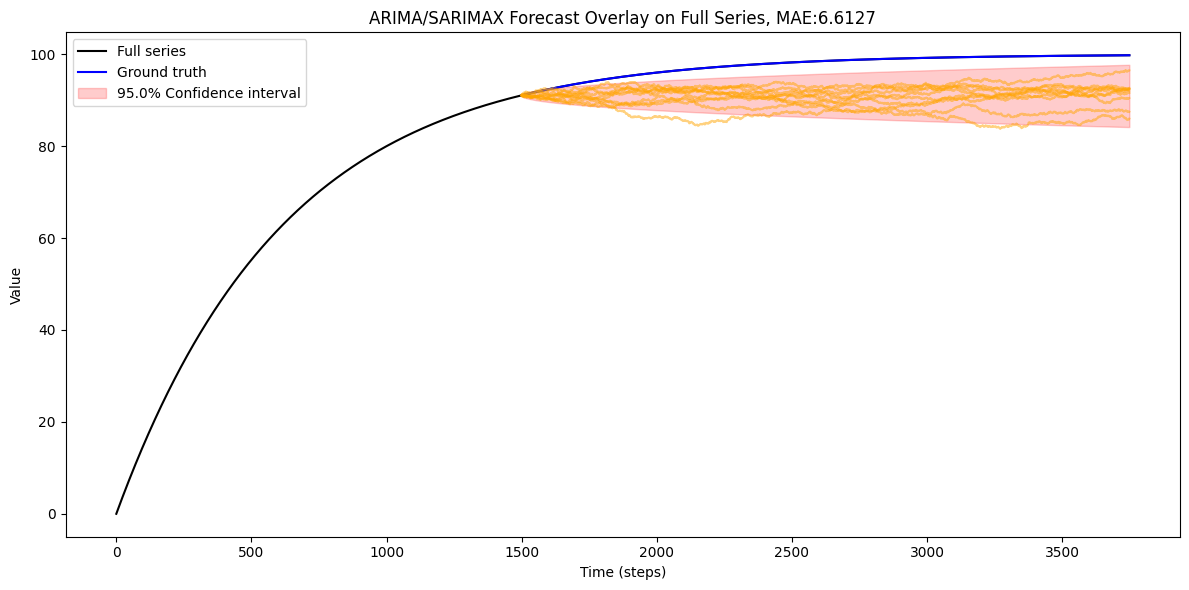

In [ ]:
utils.plot_arima_simulated_forecast(series, result,t=t,n_sim=10)